In [1]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.constants as sc
import time
import sys
import pybamm
import importlib

sys.path.append('..')
import plot_settings
plot_settings.apply()


import sim_PyBaMM
importlib.reload(sim_PyBaMM)

import exp_pybamm_ver3
importlib.reload(exp_pybamm_ver3)

import SPM_eqs
importlib.reload(SPM_eqs)

from IPython.display import display, Math
from pysr import PySRRegressor, TemplateExpressionSpec
# import mean
from pysr import jl
jl.seval("using Statistics")

/Users/jonatanharaldsson/Library/CloudStorage/OneDrive-Personal/0_Skola/Thesis/MSc_thesis/program/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/Users/jonatanharaldsson/Library/CloudStorage/OneDrive-Personal/0_Skola/Thesis/MSc_thesis/program/.venv/lib/python3.12/site-packages/juliacall/__init__.py:61: UserWarning: torch was imported before juliacall. This may cause a segfault. To avoid this, import juliacall before importing torch. For updates, see https://github.com/pytorch/pytorch/issues/78829.
  warnings.warn(


Detected IPython. Loading juliacall extension. See https://juliapy.github.io/PythonCall.jl/stable/compat/#IPython


## The goal here 

$\dot{c}_p = f(I,\dot{I},c_n,\dot{c}_n, \widetilde{D})$ and $\dot{c}_n = f(I,\dot{I},c_p,\dot{c}_p,\widetilde{D})$ and 

In [2]:
def load_data(path):
    data = np.load(path)
    return data['I'], data['dI'], data['V'], data['cn'], data['cn_dot'], data['cp'], data['cp_dot'], data['valid']

I, dI, V, cn, cn_dot, cp, cp_dot, valid = load_data('Euler_data/data_GRF_SPM.npz')
# I, dI, V, cn, cn_dot, cp, cp_dot, valid = load_data('t=5e3_GRF_data_c_dot.npz')

I = I[valid][-25000:]
dI = dI[valid][-25000:]
V = V[valid][-25000:]
cn = cn[valid][-25000:]
cn_dot = cn_dot[valid][-25000:]
cp = cp[valid][-25000:]
cp_dot = cp_dot[valid][-25000:]



print(I.shape)
print(dI.shape)
print(V.shape)
print(cn.shape)
print(cn_dot.shape)
print(cp.shape)
print(cp_dot.shape)

(25000, 1)
(25000, 1)
(25000, 1)
(25000, 1)
(25000, 1)
(25000, 1)
(25000, 1)


In [3]:
sol,model_,param = sim_PyBaMM.simulate_DC1(0.5, T=1000, T_horizon=3600)   # simulate with t_eval = np.linspace(0, t_horizon, T)
Dn = sol.observe(model_.variables["X-averaged negative particle effective diffusivity [m2.s-1]"])([0,3600])[-1, 0]
Dp = sol.observe(model_.variables["X-averaged positive particle effective diffusivity [m2.s-1]"])([0,3600])[-1, 0]
cn_norm = cn / param['Maximum concentration in negative electrode [mol.m-3]']
cp_norm = cp / param['Maximum concentration in positive electrode [mol.m-3]']

In [4]:
def condition(cp = cp,cn = cn,I = I, cn_dot = cn_dot, cp_dot = cp_dot,param = param):
    Dp = sol.observe(model_.variables["X-averaged positive particle effective diffusivity [m2.s-1]"])([0,3600])[-1, 0]
    Dn = sol.observe(model_.variables["X-averaged negative particle effective diffusivity [m2.s-1]"])([0,3600])[-1, 0]
    cnmax = param['Maximum concentration in negative electrode [mol.m-3]']
    cpmax = param['Maximum concentration in positive electrode [mol.m-3]']
    Lp = param['Positive electrode thickness [m]']
    Ln = param['Negative electrode thickness [m]']
    Rk = param['Negative particle radius [m]']
    en = param['Negative electrode active material volume fraction']
    ep = param['Positive electrode active material volume fraction']
    F = sc.physical_constants['Faraday constant'][0]
    ap = 3 * ep / Rk
    an = 3 * en / Rk

    jp = I / (ap * Lp * F)
    jn = I / (an * Ln * F)
    return Dn/Dp * (cn_dot + 2  * jn / Rk)  + (cp_dot + 2 * jp / Rk)

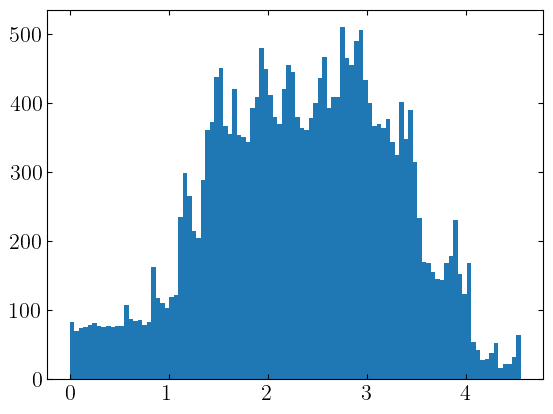

8.315412698582618e-07 4.558643822003958


In [5]:
plt.hist(condition().flatten(), bins=100)
plt.show()

print(np.min(condition()), np.max(condition()))


In [25]:
a = np.linspace(-1,1,1000).reshape(-1,1); a0 = np.linspace(0,1,1000); b = np.linspace(-1,1,1000); b0 = np.linspace(0,1,1000) 

cnmax = param['Maximum concentration in negative electrode [mol.m-3]']
cpmax = param['Maximum concentration in positive electrode [mol.m-3]']

X = np.hstack((cn/cnmax, cp/cpmax, I, cn_dot,dI))
y = cp_dot

In [26]:
model_p = PySRRegressor(
    model_selection="best",
    niterations=50,
    binary_operators=[
        "+", "*", '-','/'
    ],
    unary_operators=['square','cube','sqrt'],
    loss="loss(x, y) = (x - y)^2",
    populations=10,
    verbosity=0,
)


model_p.fit(X, y)
y = y.ravel()

<IPython.core.display.Math object>

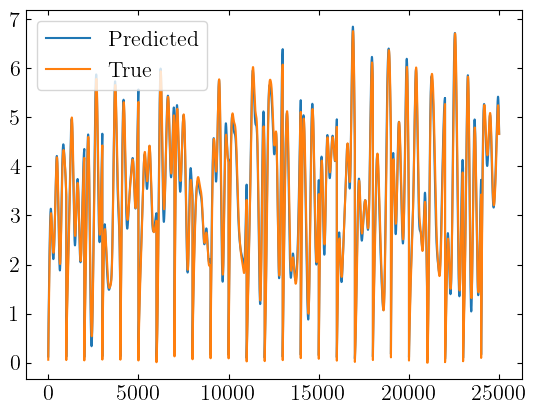

In [27]:
model_index = None
display(Math('\\Large \\mathrm{Positive:}\\quad ' + model_p.latex(model_index)))

plt.plot(model_p.predict(X), label='Predicted')
plt.plot(y, label='True')
plt.legend()
plt.show()

In [28]:
preds = model_p.predict(X)
error = preds - y.ravel()
print(error.shape)

(25000,)


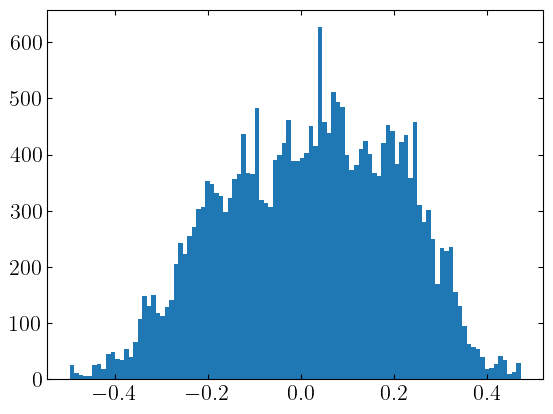

In [29]:
plt.hist(error,bins=100, label='Error')
plt.show()

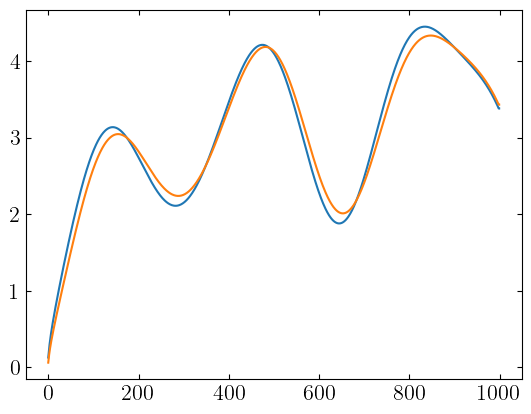

In [32]:
plt.plot(preds[:1000])
plt.plot(y.ravel()[:1000])